In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

import PIL
from PIL import Image

import os
from os.path import join, exists
from tqdm import tqdm

seed = 42
np.random.seed(seed)

In [8]:
from google.colab import drive
drive.mount('/content/drive')

# get data and unzip (if not already)
if not exists('data_cleaned'):
  !unzip "/content/drive/My Drive/aps360/project_data_final"
else:
  print('Data already loaded')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data already loaded


In [9]:
BASE_DATA_PATH = 'data_cleaned'
IMAGE_PATH = join(BASE_DATA_PATH, 'images')
ANNOT_PATH = join(BASE_DATA_PATH, 'annotations')

In [10]:
df = pd.read_csv(join(ANNOT_PATH, 'master_alternate_augmented.csv'))
df['label'].value_counts()
mask = df['label'] == 'no finding'
idx = np.where(mask)[0]
idx = idx[::2]
mask = mask[idx]


In [11]:
# df = pd.read_csv(join(ANNOT_PATH, 'master_alternate_augmented.csv'))
# n = len(df)
# value_counts = df['label'].value_counts()
# print(f"Total Samples: {n}")
# print(value_counts)

In [12]:
from skimage import io
from skimage.transform import resize
from copy import deepcopy

df_new = deepcopy(df)
# DESIRED_IMG_SIZE = (520,400)
DESIRED_IMG_SIZE = (130, 100)

save_dir = 'data_small'
if not exists(save_dir):
  os.mkdir(save_dir)

for i in tqdm(range(len(df))):
  row = df.iloc[i]
  fname = row['filename']
  if exists(join(save_dir, fname)):
    continue
  # load image
  img_path = os.path.join(IMAGE_PATH, fname)
  img = Image.open(img_path).convert('L')
  img = np.array(img)
  # resize
  img_resized = resize(img, DESIRED_IMG_SIZE, anti_aliasing=True)
  img_resized = (img_resized * 255).astype(np.uint8)
  scaled_x = img_resized.shape[0] / img.shape[0]
  scaled_y = img_resized.shape[1] / img.shape[1]
  # save
  save_path = join(save_dir, fname)
  Image.fromarray(img_resized).save(save_path)
  # update bbox in df_new if needed
  if df_new.iloc[i]['has bbox']:
    df_new.at[i, 'min_x'] = df_new.iloc[i]['min_x'] * scaled_x
    df_new.at[i, 'min_y'] = df_new.iloc[i]['min_y'] * scaled_y
    df_new.at[i, 'width'] = df_new.iloc[i]['width'] * scaled_x
    df_new.at[i, 'height'] = df_new.iloc[i]['height'] * scaled_y

100%|██████████| 21740/21740 [03:42<00:00, 97.75it/s] 


In [13]:
IMAGE_PATH = join('data_small')

In [14]:
# load images and labels
images = []
labels = []

for i in tqdm(range(len(df))):
    row = df.iloc[i]
    fname = row['filename']
    # image
    img_path = join(IMAGE_PATH, fname)
    img = np.array(Image.open(img_path).convert("L")).flatten()
    images.append(img)
    # label
    labels.append(row['label'])
images = np.array(images)

100%|██████████| 21740/21740 [00:10<00:00, 2068.07it/s]


In [15]:
frac_train = 0.7
frac_val = 0.15
frac_test = 0.15

label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

X_train, X_tmp, Y_train, Y_tmp = train_test_split(images, labels, test_size=frac_val+frac_test)
X_valid, X_test, Y_valid, Y_test = train_test_split(X_tmp, Y_tmp, test_size=frac_val/(frac_val+frac_test))

print(f"Number of Training: {len(Y_train)}")
print(f"Number of Validation: {len(Y_valid)}")
print(f"Number of Testing: {len(Y_test)}")

Number of Training: 15218
Number of Validation: 3261
Number of Testing: 3261


In [16]:
uv, vc = np.unique(Y_train, return_counts=True)
for u, v in zip(uv, vc):
  print(f"{u}: {v}")

bronchiolitis: 1513
bronchitis: 1507
broncho-pnuemonia: 1512
consolidation: 1517
effusion: 1552
heart disease: 1540
infiltration: 1511
no finding: 1553
other: 1507
pneumonia: 1506


In [17]:
# hyperparameters to try
# hyp_n_estimators = [60, 80, 100, 120, 140]
# max_depths = [10, 15, 30]
hyp_n_estimators = [140]
max_depths = [30]

val_acc = []

for n_est in tqdm(hyp_n_estimators):
  for max_depth in max_depths:
    rfc = RandomForestClassifier(n_estimators=n_est, random_state=seed,
                                 max_depth=max_depth, n_jobs=-1)
    rfc.fit(X_train, Y_train)
    Y_valid_pred = rfc.predict(X_valid)
    acc = accuracy_score(Y_valid, Y_valid_pred)
    val_acc.append((n_est, max_depth, acc))
    print(f"n_estimators: {n_est}, max_depth: {max_depth}, val_acc: {acc:.4f}")

100%|██████████| 1/1 [03:28<00:00, 208.05s/it]

n_estimators: 140, max_depth: 30, val_acc: 0.4879


In [18]:
# fit best classifier
rfc = RandomForestClassifier(n_estimators=140, random_state=seed,
                              max_depth=30, n_jobs=-1)
rfc.fit(X_train, Y_train)
Y_test_pred = rfc.predict(X_test)
acc = accuracy_score(Y_test, Y_test_pred)
print(f"Test accuracy: {acc:.4f}")

Test accuracy: 0.4943


In [19]:
from sklearn.metrics import classification_report

# Generate the classification report for all classes
class_report = classification_report(Y_test, Y_test_pred, digits=4)

print("Classification Report for all classes:")
print(class_report)


Classification Report for all classes:
                   precision    recall  f1-score   support

    bronchiolitis     0.3846    0.5167    0.4410       329
       bronchitis     0.3966    0.4047    0.4006       341
broncho-pnuemonia     0.3278    0.3113    0.3194       318
    consolidation     0.4380    0.5164    0.4740       335
         effusion     0.4194    0.5314    0.4688       318
    heart disease     0.5732    0.6174    0.5945       298
     infiltration     0.3386    0.2576    0.2926       330
       no finding     0.8290    0.7147    0.7676       312
            other     0.3257    0.1696    0.2231       336
        pneumonia     0.8845    0.9128    0.8984       344

         accuracy                         0.4943      3261
        macro avg     0.4917    0.4953    0.4880      3261
     weighted avg     0.4910    0.4943    0.4871      3261



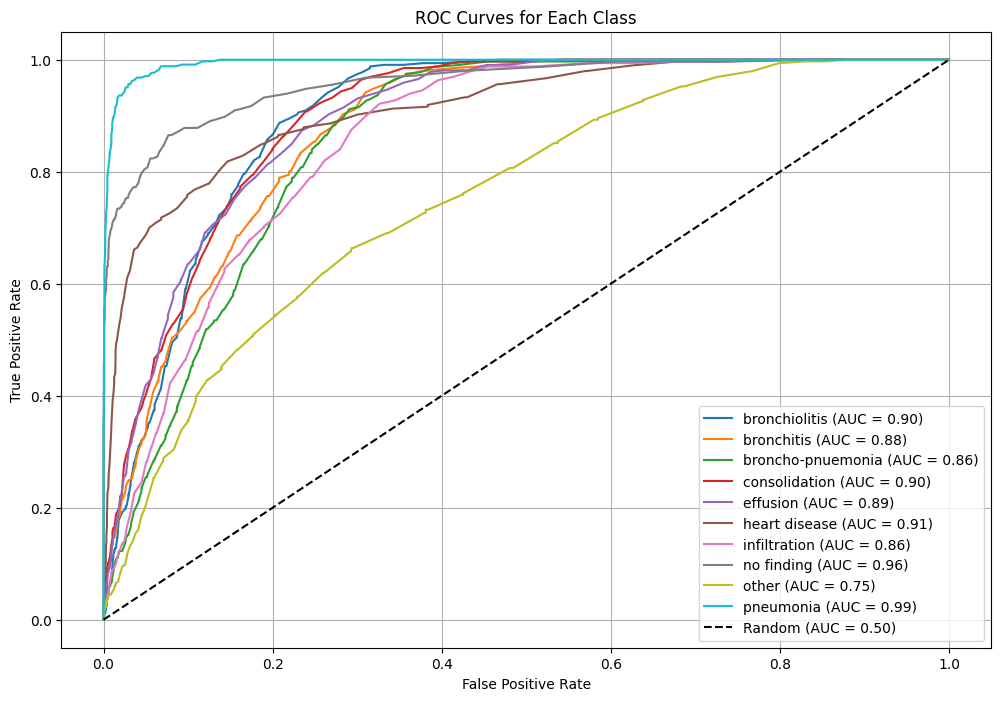

In [20]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# Get predicted probabilities for the test set
Y_test_prob = rfc.predict_proba(X_test)

# One-hot encode the true labels for multi-class AUC
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
Y_test_one_hot = ohe.fit_transform(np.array(Y_test).reshape(-1, 1))

# Get class names in the order they are encoded by OneHotEncoder
class_names = ohe.categories_[0]

# Plot ROC curve for each class
plt.figure(figsize=(12, 8))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(Y_test_one_hot[:, i], Y_test_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

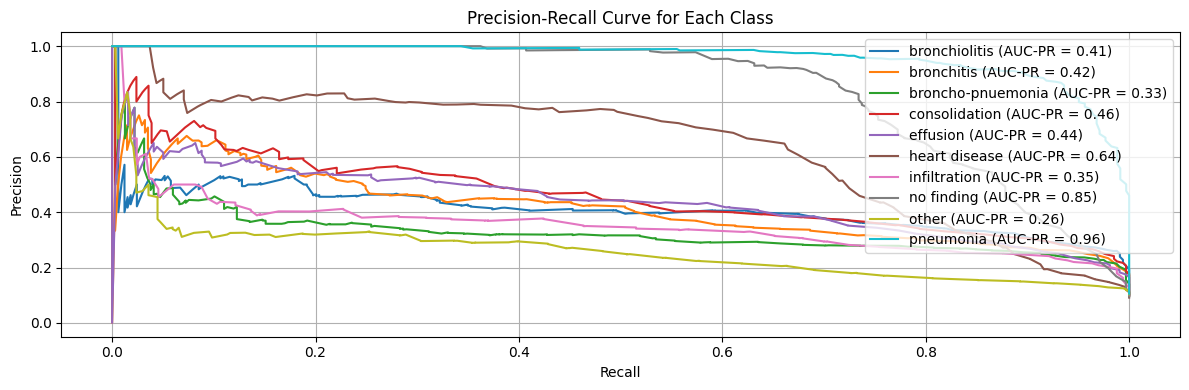

In [21]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the test set
Y_test_prob = rfc.predict_proba(X_test)

# One-hot encode the true labels for multi-class Precision-Recall
# (using the same ohe from ROC curves if available, otherwise re-initialize)
# Assuming ohe and class_names are still in scope from the previous ROC curve plotting
if 'ohe' not in locals():
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    Y_test_one_hot = ohe.fit_transform(np.array(Y_test).reshape(-1, 1))
    class_names = ohe.categories_[0]
else:
    Y_test_one_hot = ohe.transform(np.array(Y_test).reshape(-1, 1))

plt.figure(figsize=(12, 4))
for i in range(len(class_names)):
    precision, recall, _ = precision_recall_curve(Y_test_one_hot[:, i], Y_test_prob[:, i])
    # Calculate AUC for PR curve (optional, but good for comparison)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{class_names[i]} (AUC-PR = {pr_auc:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Each Class')
plt.legend(loc='upper right')
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.grid(True)
plt.show()

In [22]:
from sklearn.metrics import recall_score

# Identify 'finding' labels (all labels except 'no finding')
finding_labels = [label for label in np.unique(Y_test) if label != 'no finding']

# Create masks for 'finding' cases in Y_test and Y_test_pred
mask_findings_true = np.isin(Y_test, finding_labels)
mask_findings_pred = np.isin(Y_test_pred, finding_labels)

# Filter Y_test and Y_test_pred for 'finding' cases
Y_test_findings = np.array(Y_test)[mask_findings_true]
Y_test_pred_findings = Y_test_pred[mask_findings_true]

# Calculate recall score for 'finding' labels
recall_findings = recall_score(Y_test_findings, Y_test_pred_findings, average='weighted', labels=finding_labels)

print(f"Recall score for tests with findings: {recall_findings:.4f}")

Recall score for tests with findings: 0.4710
